In [4]:
!pip -q install tensorflow tensorflow-datasets hdbscan librosa

In [5]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
from itertools import combinations

import tensorflow as tf
import tensorflow_datasets as tfds
import librosa

from sklearn.preprocessing import normalize
from sklearn.random_projection import SparseRandomProjection
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

try:
    import hdbscan
    HDBSCAN_AVAILABLE = True
except Exception as e:
    HDBSCAN_AVAILABLE = False
    print("HDBSCAN not available:", e)

In [6]:
SELECTED_LABELS = ["yes", "no", "up", "down"]
label_to_id = {lab: i for i, lab in enumerate(SELECTED_LABELS)}

train_ds, ds_info = tfds.load(
    "speech_commands",
    split="train",
    with_info=True,
    as_supervised=False
)

print(ds_info)

tfds.core.DatasetInfo(
    name='speech_commands',
    full_name='speech_commands/0.0.3',
    description="""
    An audio dataset of spoken words designed to help train and evaluate keyword
    spotting systems. Its primary goal is to provide a way to build and test small
    models that detect when a single word is spoken, from a set of ten target words,
    with as few false positives as possible from background noise or unrelated
    speech. Note that in the train and validation set, the label "unknown" is much
    more prevalent than the labels of the target words or background noise. One
    difference from the release version is the handling of silent segments. While in
    the test set the silence segments are regular 1 second files, in the training
    they are provided as long segments under "background_noise" folder. Here we
    split these background noise into 1 second clips, and also keep one of the files
    for the validation set.
    """,
    homepage='https://arxiv.or

In [15]:
MAX_PER_CLASS = 1500
FIXED_LEN = 16000

waveforms = []
y_true = []

class_counts = {lab: 0 for lab in SELECTED_LABELS}

label_feature = ds_info.features["label"]

for ex in tfds.as_numpy(train_ds):
    label_name = label_feature.int2str(int(ex["label"]))

    if label_name not in SELECTED_LABELS:
        continue

    if class_counts[label_name] >= MAX_PER_CLASS:
        continue

    audio = ex["audio"].astype(np.float32)

    if len(audio) < FIXED_LEN:
        audio = np.pad(audio, (0, FIXED_LEN - len(audio)))
    else:
        audio = audio[:FIXED_LEN]

    waveforms.append(audio)
    y_true.append(label_to_id[label_name])
    class_counts[label_name] += 1

    if all(class_counts[lab] >= MAX_PER_CLASS for lab in SELECTED_LABELS):
        break

waveforms = np.array(waveforms, dtype=np.float32)
y_true = np.array(y_true)

print("Waveforms shape:", waveforms.shape)
print("Labels:", SELECTED_LABELS)
print("Counts:", {lab: int(sum(y_true == idx)) for lab, idx in label_to_id.items()})

Waveforms shape: (6000, 16000)
Labels: ['yes', 'no', 'up', 'down']
Counts: {'yes': 1500, 'no': 1500, 'up': 1500, 'down': 1500}


In [16]:
def extract_logmel_features(
    waveforms,
    sr=16000,
    n_mels=64,
    n_fft=512,
    hop_length=160,
    win_length=400
):
    feats = []
    for x in waveforms:
        mel = librosa.feature.melspectrogram(
            y=x,
            sr=sr,
            n_fft=n_fft,
            hop_length=hop_length,
            win_length=win_length,
            n_mels=n_mels,
            power=2.0
        )
        logmel = librosa.power_to_db(mel, ref=np.max)
        feats.append(logmel.flatten())

    if len(feats) == 0:
        return np.empty((0, 0), dtype=np.float32)

    return np.array(feats, dtype=np.float32)


X_feat = extract_logmel_features(waveforms, sr=TARGET_SR)

if X_feat.shape[0] > 0:
    X_feat = normalize(X_feat, norm="l2", axis=1)

print("Feature shape:", X_feat.shape)

Feature shape: (6000, 6464)


In [17]:
JL_DIM = 512

rp = SparseRandomProjection(
    n_components=JL_DIM,
    dense_output=True,
    random_state=42
)

t0 = time.perf_counter()
X_jl = rp.fit_transform(X_feat)
jl_time = time.perf_counter() - t0

X_jl = normalize(X_jl, norm="l2", axis=1)

print("JL shape:", X_jl.shape)
print("JL transform time:", jl_time)

JL shape: (6000, 512)
JL transform time: 0.8866320869992705


Mean abs distortion: 0.0039135944
95% abs distortion: 0.009327878


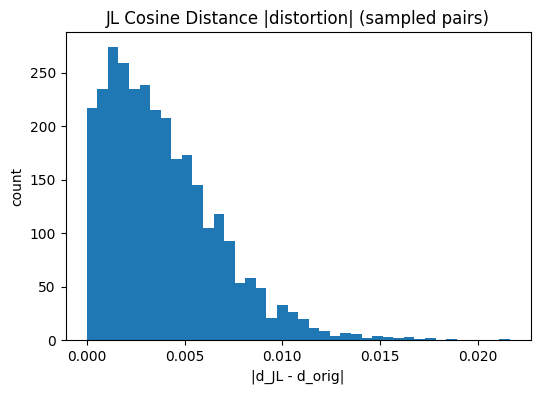

In [18]:
rng = np.random.default_rng(0)
n = X_feat.shape[0]
pairs = 3000

idx_a = rng.integers(0, n, size=pairs)
idx_b = rng.integers(0, n, size=pairs)

orig_sim = np.sum(X_feat[idx_a] * X_feat[idx_b], axis=1)
orig_dist = 1.0 - orig_sim

jl_sim = np.sum(X_jl[idx_a] * X_jl[idx_b], axis=1)
jl_dist = 1.0 - jl_sim

distortion = jl_dist - orig_dist
abs_distortion = np.abs(distortion)

print("Mean abs distortion:", abs_distortion.mean())
print("95% abs distortion:", np.quantile(abs_distortion, 0.95))

plt.figure(figsize=(6,4))
plt.hist(abs_distortion, bins=40)
plt.title("JL Cosine Distance |distortion| (sampled pairs)")
plt.xlabel("|d_JL - d_orig|")
plt.ylabel("count")
plt.show()

In [19]:
k = len(np.unique(y_true))

t0 = time.perf_counter()
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
y_km = kmeans.fit_predict(X_jl)
km_time = time.perf_counter() - t0

print("KMeans time:", km_time)

if HDBSCAN_AVAILABLE:
    t0 = time.perf_counter()
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=15,
        min_samples=5,
        metric="euclidean"
    )
    y_hdb = clusterer.fit_predict(X_jl)
    hdb_time = time.perf_counter() - t0

    print("HDBSCAN time:", hdb_time)
    print("HDBSCAN clusters (excluding -1 noise):", len(set(y_hdb)) - (1 if -1 in y_hdb else 0))
else:
    y_hdb = None
    hdb_time = None

KMeans time: 1.947917082999993
HDBSCAN time: 50.51423988099941
HDBSCAN clusters (excluding -1 noise): 2


In [20]:
def random_hyperplane_hash(X, hyperplanes):
    proj = X @ hyperplanes.T
    return proj >= 0.0

def bits_to_int(bit_row):
    out = 0
    for b in bit_row:
        out = (out << 1) | int(b)
    return out

def lsh_candidate_buckets(bits, band_size):
    n, n_bits = bits.shape
    assert n_bits % band_size == 0
    n_bands = n_bits // band_size

    tables = []
    for b in range(n_bands):
        start = b * band_size
        end = start + band_size
        table = defaultdict(list)
        for i in range(n):
            key = bits_to_int(bits[i, start:end])
            table[key].append(i)
        tables.append(table)
    return tables

def build_candidate_pairs(tables, max_bucket_size=200):
    cand = set()
    for table in tables:
        for _, idxs in table.items():
            if len(idxs) < 2:
                continue
            if len(idxs) > max_bucket_size:
                continue
            for i, j in combinations(idxs, 2):
                if i < j:
                    cand.add((i, j))
                else:
                    cand.add((j, i))
    return cand

def connected_components(n, edges):
    parent = np.arange(n)

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for i, j in edges:
        union(i, j)

    roots = np.array([find(i) for i in range(n)])
    _, labels = np.unique(roots, return_inverse=True)
    return labels

In [21]:
N_BITS = 96
BAND_SIZE = 12
COS_THRESHOLD = 0.70
MAX_BUCKET = 250

rng = np.random.default_rng(42)
d = X_jl.shape[1]

hyperplanes = rng.normal(size=(N_BITS, d)).astype(np.float32)
hyperplanes /= np.linalg.norm(hyperplanes, axis=1, keepdims=True) + 1e-12

t0 = time.perf_counter()

bits = random_hyperplane_hash(X_jl, hyperplanes)
tables = lsh_candidate_buckets(bits, band_size=BAND_SIZE)
cand_pairs = build_candidate_pairs(tables, max_bucket_size=MAX_BUCKET)

mid = time.perf_counter()

edges = []
for (i, j) in cand_pairs:
    sim = float(np.dot(X_jl[i], X_jl[j]))
    if sim >= COS_THRESHOLD:
        edges.append((i, j))

y_lsh = connected_components(n=X_jl.shape[0], edges=edges)

lsh_time = time.perf_counter() - t0
hash_time = mid - t0
refine_time = lsh_time - hash_time

print("LSH candidates:", len(cand_pairs))
print("LSH edges kept:", len(edges))
print("LSH clusters:", len(np.unique(y_lsh)))
print("LSH time total:", lsh_time)
print("Hash time:", hash_time)
print("Refine time:", refine_time)

LSH candidates: 388216
LSH edges kept: 388216
LSH clusters: 1474
LSH time total: 6.239214856000217
Hash time: 0.5170770160002576
Refine time: 5.722137839999959


In [22]:
def purity_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    N = len(y_true)
    total = 0
    for c in np.unique(y_pred):
        idx = np.where(y_pred == c)[0]
        if len(idx) == 0:
            continue
        _, counts = np.unique(y_true[idx], return_counts=True)
        total += counts.max()
    return total / N

def safe_silhouette(X, labels):
    labels = np.asarray(labels)
    if len(np.unique(labels)) < 2:
        return np.nan
    return silhouette_score(X, labels, metric="euclidean")

In [23]:
rows = []

rows.append({
    "method": "KMeans (on JL)",
    "time_sec": km_time,
    "ARI": adjusted_rand_score(y_true, y_km),
    "NMI": normalized_mutual_info_score(y_true, y_km),
    "Purity": purity_score(y_true, y_km),
    "Silhouette": safe_silhouette(X_jl, y_km),
    "n_clusters": len(np.unique(y_km))
})

if HDBSCAN_AVAILABLE and y_hdb is not None:
    y_hdb_non_noise = y_hdb[y_hdb != -1]
    X_hdb_non_noise = X_jl[y_hdb != -1]

    sil = np.nan
    if len(np.unique(y_hdb_non_noise)) >= 2 and len(y_hdb_non_noise) > 1:
        sil = silhouette_score(X_hdb_non_noise, y_hdb_non_noise, metric="euclidean")

    rows.append({
        "method": "HDBSCAN (on JL)",
        "time_sec": hdb_time,
        "ARI": adjusted_rand_score(y_true, y_hdb),
        "NMI": normalized_mutual_info_score(y_true, y_hdb),
        "Purity": purity_score(y_true, y_hdb),
        "Silhouette": sil,
        "n_clusters": len(set(y_hdb)) - (1 if -1 in y_hdb else 0)
    })

rows.append({
    "method": "JL + Random-Hyperplane LSH (custom)",
    "time_sec": lsh_time,
    "ARI": adjusted_rand_score(y_true, y_lsh),
    "NMI": normalized_mutual_info_score(y_true, y_lsh),
    "Purity": purity_score(y_true, y_lsh),
    "Silhouette": safe_silhouette(X_jl, y_lsh),
    "n_clusters": len(np.unique(y_lsh))
})

results = pd.DataFrame(rows).sort_values("time_sec")
results

,method,time_sec,ARI,NMI,Purity,Silhouette,n_clusters
0,KMeans (on JL),1.947917,0.003800,0.004828,0.281000,0.142736,4
2,JL + Random-Hyperplane LSH (custom),6.239215,0.002313,0.183036,0.454833,-0.406574,1474
1,HDBSCAN (on JL),50.514240,0.039613,0.046059,0.341833,0.120451,2


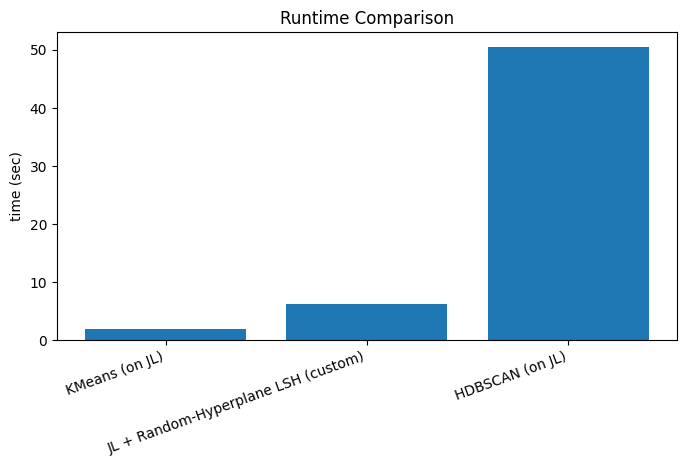

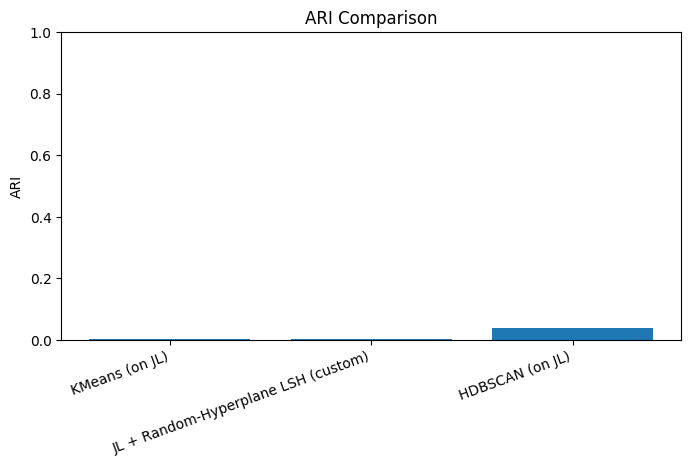

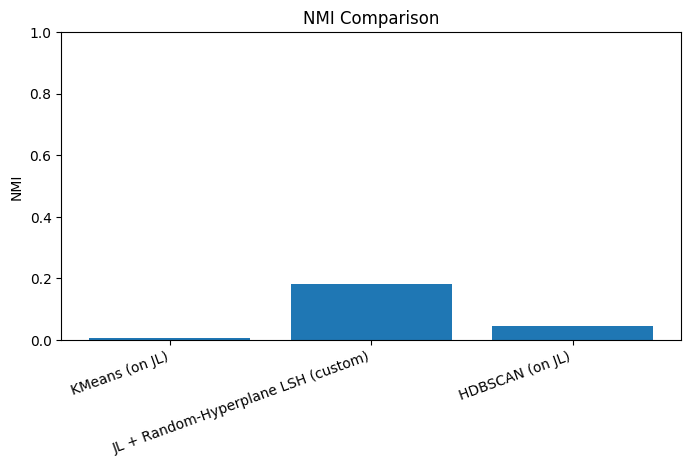

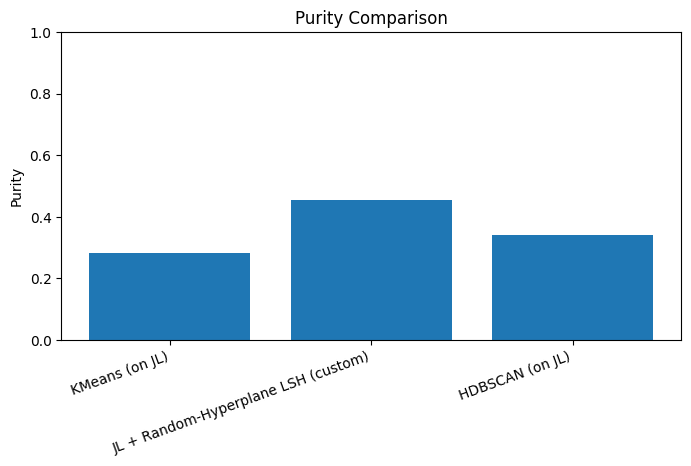

In [24]:
plt.figure(figsize=(8,4))
plt.bar(results["method"], results["time_sec"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("time (sec)")
plt.title("Runtime Comparison")
plt.show()

for metric in ["ARI", "NMI", "Purity"]:
    plt.figure(figsize=(8,4))
    plt.bar(results["method"], results[metric])
    plt.xticks(rotation=20, ha="right")
    plt.ylabel(metric)
    plt.title(f"{metric} Comparison")
    plt.ylim(0, 1.0)
    plt.show()

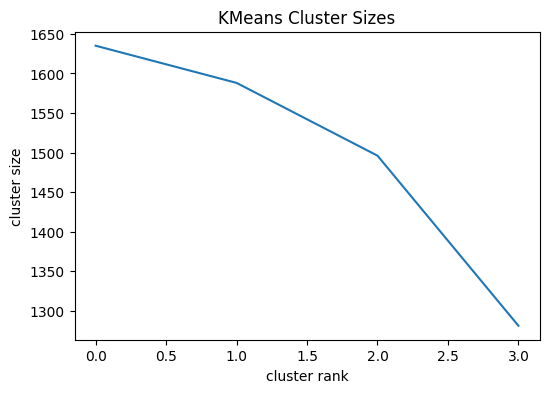

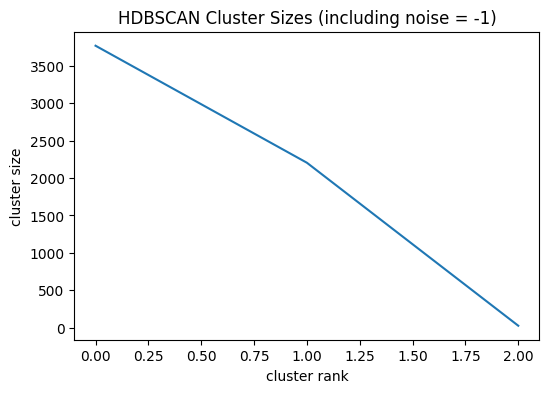

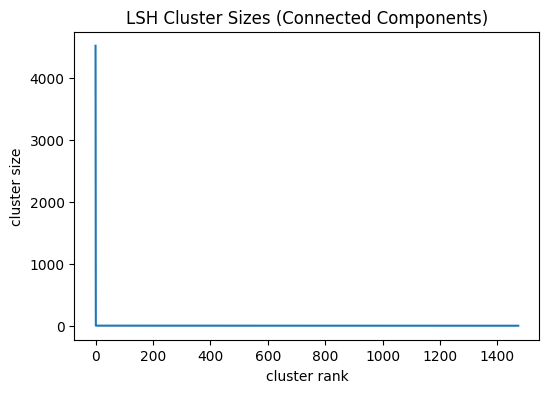

In [25]:
def plot_cluster_sizes(labels, title):
    labels = np.asarray(labels)
    _, counts = np.unique(labels, return_counts=True)
    counts = np.sort(counts)[::-1]
    plt.figure(figsize=(6,4))
    plt.plot(counts)
    plt.xlabel("cluster rank")
    plt.ylabel("cluster size")
    plt.title(title)
    plt.show()

plot_cluster_sizes(y_km, "KMeans Cluster Sizes")

if HDBSCAN_AVAILABLE and y_hdb is not None:
    plot_cluster_sizes(y_hdb, "HDBSCAN Cluster Sizes (including noise = -1)")

plot_cluster_sizes(y_lsh, "LSH Cluster Sizes (Connected Components)")

In [26]:
def augment_audio(x, noise_std=0.01, shift=400, seed=0):
    rng = np.random.default_rng(seed)
    y = x.copy()
    y = np.roll(y, shift)
    y = y + rng.normal(0, noise_std, size=len(y)).astype(np.float32)
    y = np.clip(y, -1.0, 1.0)
    return y

dup_count = 120
rng = np.random.default_rng(123)
base_idx = rng.choice(len(waveforms), size=dup_count, replace=False)

dup_waveforms = [
    augment_audio(waveforms[i], noise_std=0.01, shift=200, seed=int(i))
    for i in base_idx
]

aug_waveforms = np.concatenate([waveforms, np.array(dup_waveforms, dtype=np.float32)], axis=0)

N0 = len(waveforms)
dup_pairs = [(int(i), N0 + k) for k, i in enumerate(base_idx)]

X_aug = extract_logmel_features(aug_waveforms, sr=TARGET_SR)
X_aug = normalize(X_aug, norm="l2", axis=1)

X_aug_jl = rp.fit_transform(X_aug)
X_aug_jl = normalize(X_aug_jl, norm="l2", axis=1)

t0 = time.perf_counter()

bits_aug = random_hyperplane_hash(X_aug_jl, hyperplanes)
tables_aug = lsh_candidate_buckets(bits_aug, band_size=BAND_SIZE)
cand_aug = build_candidate_pairs(tables_aug, max_bucket_size=MAX_BUCKET)

edges_aug = []
for (i, j) in cand_aug:
    if float(np.dot(X_aug_jl[i], X_aug_jl[j])) >= COS_THRESHOLD:
        edges_aug.append((i, j))

labels_aug = connected_components(n=X_aug_jl.shape[0], edges=edges_aug)
dup_time = time.perf_counter() - t0

hits = sum(1 for a, b in dup_pairs if labels_aug[a] == labels_aug[b])
dup_recall = hits / len(dup_pairs)

print("Duplicate recall (LSH components):", dup_recall)
print("Time (LSH on augmented corpus):", dup_time)

Duplicate recall (LSH components): 0.725
Time (LSH on augmented corpus): 6.19343962899984


In [27]:
results.to_csv("experiment3_speech_commands_results.csv", index=False)
print("Saved: experiment3_speech_commands_results.csv")

Saved: experiment3_speech_commands_results.csv
